In [2]:
import joblib
import pandas as pd

model = joblib.load("../models/credit_model.pkl")
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")
X= df.drop('loan_status', axis=1)
y= df['loan_status']

In [12]:
X_sample = X.sample(2000, random_state=42)
import shap
explainer = shap.TreeExplainer(model.named_steps['clf'])
X_transformed = model.named_steps['preprocess'].transform(X_sample)
shap_values = explainer.shap_values(X_transformed)


In [14]:
preprocessor = gb_model.named_steps['preprocess']
clf = gb_model.named_steps['clf']

# Transform data the same way pipeline does
X_t = preprocessor.transform(X_sample)

import shap
explainer = shap.TreeExplainer(clf)

shap_values = explainer.shap_values(X_t)

# Get transformed feature names so plot is readable
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(shap_values, X_t, feature_names=feature_names)


NameError: name 'gb_model' is not defined

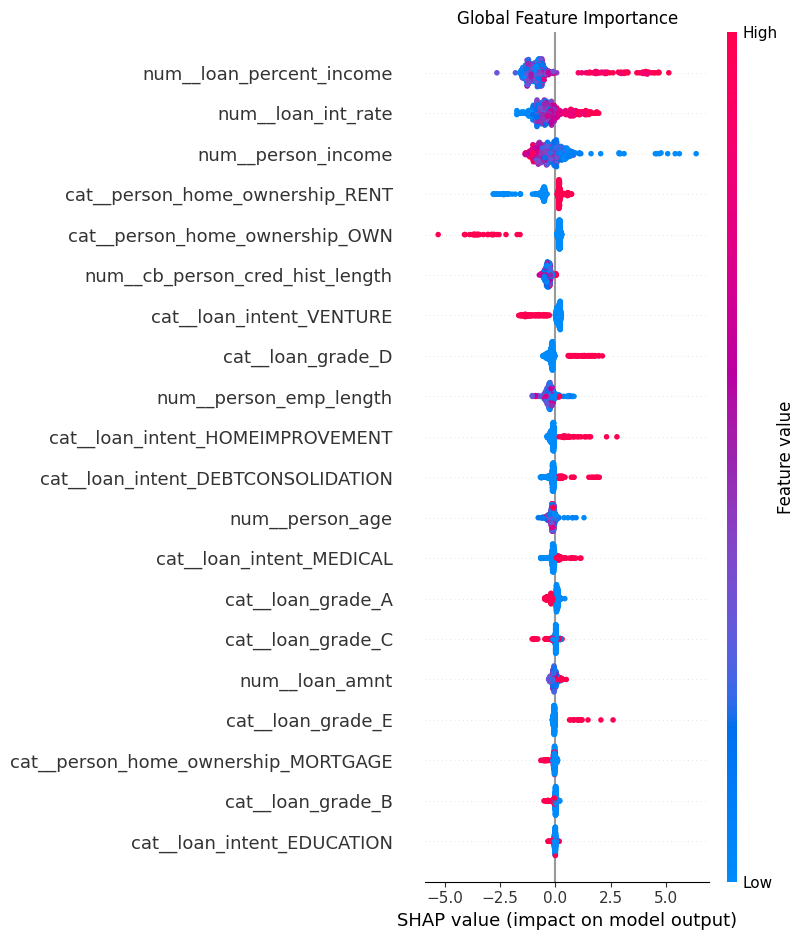

In [9]:
import shap
import matplotlib.pyplot as plt
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

plt.title("Global Feature Importance")
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, show=False)

plt.savefig("../figures/global_importance.png", dpi=300, bbox_inches='tight')
plt.show()


TypeError: The waterfall plot requires an `Explanation` object as the `shap_values` argument.